In [66]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph ,START, END 
from typing import TypedDict , Annotated , operator ,Literal
from pydantic import BaseModel, Field

from dotenv import load_dotenv
load_dotenv(override=True)
import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
model=ChatGroq(model="llama-3.1-8b-instant")


In [67]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="The sentiment of the text")

In [68]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug"] = Field(description="The type of issue in the review")
    tone: Literal["formal", "informal", "frustrated"] = Field(description="The tone of the review")
    urgency: Literal["low", "medium", "high"] = Field(description="The urgency of the issue in the review")

In [69]:
 structured_model =model.with_structured_output(SentimentSchema)
 structured_model_2 = model.with_structured_output(DiagnosisSchema)

In [71]:
prompt = 'what is the sentiment of flowing review - The software isnotgood'
structured_model.invoke(prompt).sentiment



'negative'

In [ ]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis:dict
    response:str


In [ ]:
def find_sentiment(state:ReviewState):
    prompt = f'for the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment':sentiment}

def check_sentiment(state:ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

def positive_response(state:ReviewState):

    prompt = f"""write a warm thank-you message in response to this review:
    \n\n"{state['review']}\"\n
    Also ,kindly ask the user to leave feedback on our website if they have time.
    """
    response = model.invoke(prompt).content
    return {'response':response}
    
def run_diagnosis(state:ReviewState):

    prompt = f"""
    Diagnose the following negative review \n\n{state['review']}\n"
    "Return issue_type ,tone and urgency
    """

    response = structured_model_2.invoke(prompt)
    return {'diagnosis':response.model_dump()}

def negative_response(state:ReviewState):

    diagnosis = state['diagnosis']
    prompt = f"""  you are a suppport assistant.
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and the issue urgency is '{diagnosis['urgency']}'.
    write an empathetic, helpful resolution message.
    """
    response = model.invoke(prompt).content
    return {'response':response}




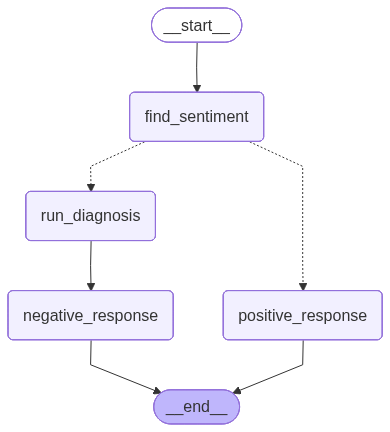

In [ ]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment',find_sentiment)
graph.add_node('positive_response',positive_response)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)


graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('positive_response',END)

graph.add_edge('run_diagnosis','negative_response') 
graph.add_edge('negative_response',END)
graph.add_edge('find_sentiment',END)
workflow = graph.compile()
workflow

In [ ]:
initial_state = {
    'review':''
}
workflow.invoke(initial_state)

{'review': 'The software is notgood',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "**Apologies for the inconvenience**\n\nI can sense that you're feeling frustrated with the issue you're experiencing. I want to assure you that I'm here to help and we'll do our best to resolve the problem as soon as possible.\n\nTo better understand the issue, can you please provide more details about the 'Bug' you're facing? This will help me to assist you more effectively. Please share any relevant information, such as the steps you've taken so far, any error messages you've encountered, and the specific features or functionalities that are affected.\n\nIn the meantime, I'd like to offer a temporary solution that might help alleviate the issue. Could you please try [insert temporary solution here]? This might help you to continue using the service while we work on a more permanent fix.\n\nI want to assure you that we take all bug